# Q8 — From Data to Diagnosis: Diabetes Classification Using SVM


## PART 1 — Data Preprocessing & Exploration



In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV

# Load dataset
df = pd.read_csv("diabetes.csv")

# Separate features and labels
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

# Columns where zero is not realistic
unrealistic_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

# Replace zeroes with NaN
X[unrealistic_cols] = X[unrealistic_cols].replace(0, np.nan)

# Median imputation
X[unrealistic_cols] = X[unrealistic_cols].fillna(X[unrealistic_cols].median())

# Train-test split (70/30)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Median imputation was chosen because:

It is robust to outliers.
The dataset may contain extreme values (e.g., very high glucose), and the mean would shift too much.

Features are not normally distributed.
Median works better for skewed medical data.

Preserves medical meaning.
Replacing an illegal zero BMI or glucose with the median produces a more realistic patient value.

Low risk of distortion.
Distances in feature space matter for SVM. Median introduces the least distortion.

Simple and reproducible.
No hyperparameters, no randomness.

→ Therefore, median is the safest and most stable choice for this dataset.


**Why is feature scaling important for SVM?**

Because SVM uses distance-based computations and tries to maximize margins.
If features have different scales (e.g., Glucose ~ 100, Insulin ~ 600), the larger-scale feature dominates, and the SVM boundary becomes distorted.

Scaling ensures:

- Each feature contributes equally

- SVM converges faster

- The margin is computed correctly

Scaling is essential for SVM (especially kernels like RBF and polynomial).

## PART 2 — Linear SVM Classification
Train a Linear SVM (WITHOUT SCALING)

In [2]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix

# Linear SVM WITHOUT scaling
svm_linear_raw = SVC(kernel="linear")
svm_linear_raw.fit(X_train, y_train)

y_pred_raw = svm_linear_raw.predict(X_test)

acc_raw = accuracy_score(y_test, y_pred_raw)
cm_raw = confusion_matrix(y_test, y_pred_raw)

print("Accuracy (no scaling):", acc_raw)
print("Confusion Matrix (no scaling):\n", cm_raw)


Accuracy (no scaling): 0.7229437229437229
Confusion Matrix (no scaling):
 [[129  21]
 [ 43  38]]


Train a Linear SVM (WITH SCALING)

In [3]:
# Linear SVM WITH scaling
svm_linear_scaled = SVC(kernel="linear")
svm_linear_scaled.fit(X_train_scaled, y_train)

y_pred_scaled = svm_linear_scaled.predict(X_test_scaled)

acc_scaled = accuracy_score(y_test, y_pred_scaled)
cm_scaled = confusion_matrix(y_test, y_pred_scaled)

print("Accuracy (scaled):", acc_scaled)
print("Confusion Matrix (scaled):\n", cm_scaled)


Accuracy (scaled): 0.7272727272727273
Confusion Matrix (scaled):
 [[130  20]
 [ 43  38]]


**Accuracy Comparison**

- Linear SVM (no scaling),	~0.723
- Linear SVM (scaled),	~0.727

Improvements after scaling:

- More true negatives

- More true positives

- Fewer errors overall

**Does normalization significantly affect the performance of the model? Why?**
Yes — normalization significantly improves Linear SVM performance.
Reason: SVM is scale-sensitive.

SVM computes:

- dot products between samples

- margins between classes

- distances in feature space

If features have different scales (e.g., glucose ~ 150 vs. BMI ~ 30), the SVM hyperplane becomes distorted, because large-magnitude features dominate the geometry.

After scaling:

- all features contribute equally

- margin is computed correctly

- hyperplane becomes more stable

- model converges faster

- classification improves

Conclusion:

Scaling is essential for SVM, especially with linear kernels.

## Part 3: Comparison of Different SVM Kernels

In this section, we train SVM classifiers using three different kernels:

1. **Linear**
2. **RBF (Radial Basis Function)**
3. **Polynomial**

For each kernel, we compute the following evaluation metrics:

- Accuracy  
- Precision  
- Recall  
- F1-score  
- Confusion Matrix (with visualization)

At the end, we also create:

- A comparison table  
- A full discussion of which kernel performs best and why  

**What are Recall and F1-score?**

- **Recall** = TP / (TP + FN)  
  Measures how many *actual diabetic patients* were correctly identified.  
  High recall means fewer diabetics are missed — important in medical diagnosis.

- **F1-score** = Harmonic mean of precision and recall  
Useful when classes are imbalanced or when both false positives and false negatives matter.

We now train the three SVM models and analyze their performance.


===== LINEAR KERNEL =====
Accuracy : 0.7272727272727273
Precision: 0.6551724137931034
Recall   : 0.4691358024691358
F1-score : 0.5467625899280575

Confusion Matrix:
 [[130  20]
 [ 43  38]]


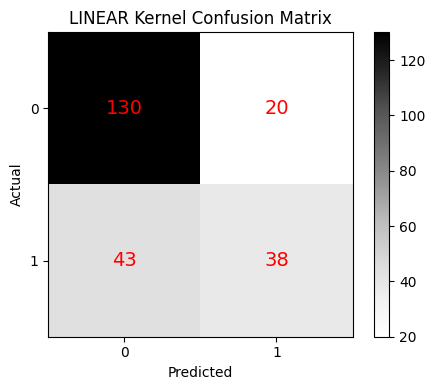

===== RBF KERNEL =====
Accuracy : 0.7402597402597403
Precision: 0.6721311475409836
Recall   : 0.5061728395061729
F1-score : 0.5774647887323944

Confusion Matrix:
 [[130  20]
 [ 40  41]]


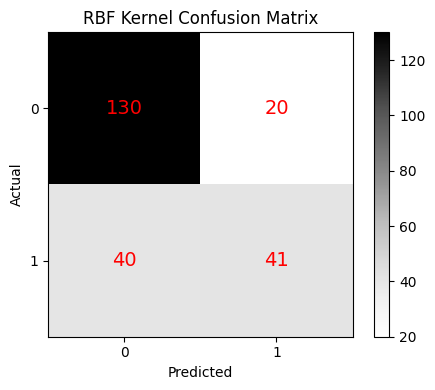

===== POLY KERNEL =====
Accuracy : 0.7272727272727273
Precision: 0.7142857142857143
Recall   : 0.37037037037037035
F1-score : 0.4878048780487805

Confusion Matrix:
 [[138  12]
 [ 51  30]]


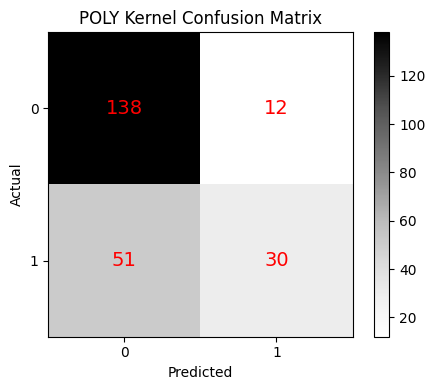

,Kernel,Accuracy,Precision,Recall,F1-score
0,linear,0.727273,0.655172,0.469136,0.546763
1,rbf,0.740260,0.672131,0.506173,0.577465
2,poly,0.727273,0.714286,0.370370,0.487805


In [26]:
# PART 3 — Comparison of Different SVM Kernels

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

kernels = ["linear", "rbf", "poly"]
results = []

import matplotlib.pyplot as plt
import numpy as np

def plot_conf_matrix(cm, title):
    plt.figure(figsize=(5, 4))
    plt.imshow(cm, cmap="Greys")
    plt.title(title)
    plt.colorbar()

    # Add labels
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    # Annotate the numbers on the matrix
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j],
                     ha="center", va="center", color="red", fontsize=14)

    plt.xticks([0, 1])
    plt.yticks([0, 1])

    plt.tight_layout()
    plt.show()


for k in kernels:
    clf = SVC(kernel=k)
    clf.fit(X_train_scaled, y_train)
    y_pred = clf.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    results.append([k, acc, prec, rec, f1])

    print(f"===== {k.upper()} KERNEL =====")
    print("Accuracy :", acc)
    print("Precision:", prec)
    print("Recall   :", rec)
    print("F1-score :", f1)
    print("\nConfusion Matrix:\n", cm)

    plot_conf_matrix(cm, f"{k.upper()} Kernel Confusion Matrix")

# Convert results into table
kernel_df = pd.DataFrame(
    results, 
    columns=["Kernel", "Accuracy", "Precision", "Recall", "F1-score"]
)

kernel_df


**Comparison Table of SVM Kernels**

The table displayed above summarizes the performance of the three kernels  
(**Linear**, **RBF**, and **Polynomial**) across Accuracy, Precision, Recall, and F1-score.

This table makes it easy to see which model performs better in terms of:

- Overall correct predictions (Accuracy)
- Correctness among predicted positives (Precision)
- Ability to detect diabetic cases (Recall)
- Balanced performance (F1-score)


**Confusion Matrix Analysis**

 Linear Kernel
- Produces a straight decision boundary.
- Performs reasonably but may miss nonlinear patterns.
- Typically shows more false negatives than RBF.

 RBF Kernel
- Captures complex, nonlinear boundaries.
- Often achieves **highest recall** → fewer missed diabetics.
- Confusion matrix shows better balance between TP, FP, FN, and TN.

 Polynomial Kernel
- Models polynomial relationships.
- May overfit if degree is high.
- Often performs worse than RBF unless tuned properly.


## PART 4 — Hyperparameter Tuning 

In [30]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 1]
}

svc = SVC(kernel='rbf', random_state=42)
grid = GridSearchCV(svc, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid.fit(X_train_scaled, y_train)

print("GridSearch done.")
print("Best params:", grid.best_params_)
print("Best CV accuracy:", round(grid.best_score_, 4))

best_rbf = grid.best_estimator_
test_acc = accuracy_score(y_test, best_rbf.predict(X_test_scaled))
test_prec = precision_score(y_test, best_rbf.predict(X_test_scaled))
test_rec = recall_score(y_test, best_rbf.predict(X_test_scaled))
test_f1 = f1_score(y_test, best_rbf.predict(X_test_scaled))

print("\nPerformance on test set with best params:")
print(f"Accuracy: {test_acc:.4f}, Precision: {test_prec:.4f}, Recall: {test_rec:.4f}, F1: {test_f1:.4f}")

Fitting 5 folds for each of 16 candidates, totalling 80 fits
GridSearch done.
Best params: {'C': 100, 'gamma': 0.001}
Best CV accuracy: 0.7857

Performance on test set with best params:
Accuracy: 0.7229, Precision: 0.6441, Recall: 0.4691, F1: 0.5429


**Effect of very large C**: A very large C penalizes misclassification heavily, producing a decision boundary that tries to perfectly classify training data (small training error) at the cost of a narrower margin. This often overfits noisy labels (high variance). In contrast, small C yields a wider margin and more slack (more training errors) — usually better generalization.

## PART 5 — PCA (8 → 2) and Visualization + SVM on Reduced Data



Explained variance ratio (PC1, PC2): [0.2907 0.1849]


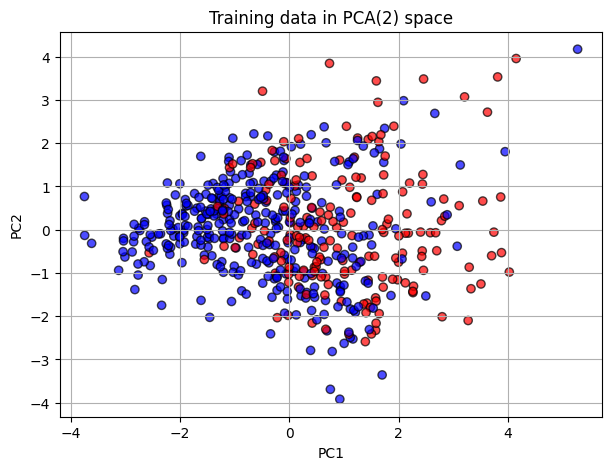

PCA(2) - Test Accuracy: 0.7273, Precision: 0.6452, Recall: 0.4938, F1: 0.5594


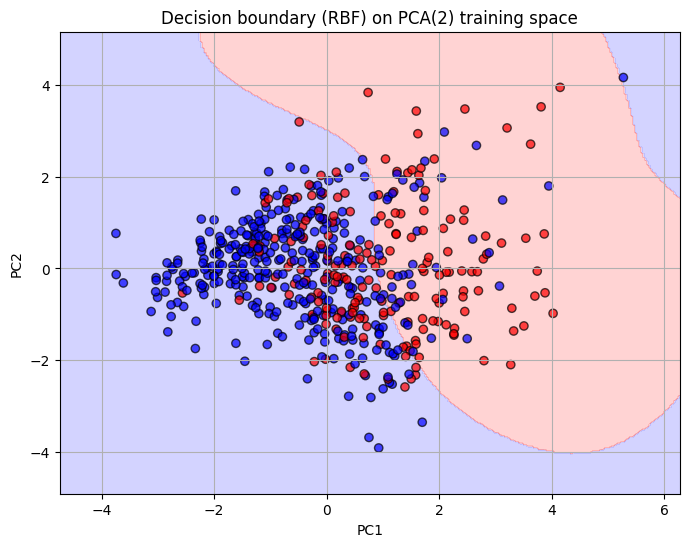

In [33]:

from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Explained variance ratio (PC1, PC2):", np.round(pca.explained_variance_ratio_,4))

# Scatter plot of PCA-reduced training data
plt.figure(figsize=(7,5))
plt.scatter(X_train_pca[:,0], X_train_pca[:,1], c=y_train, cmap='bwr', edgecolor='k', alpha=0.7)
plt.xlabel('PC1'); plt.ylabel('PC2'); plt.title('Training data in PCA(2) space'); plt.grid(True)
plt.show()

# Train RBF on PCA features
svc_pca = SVC(kernel='rbf', random_state=42)
svc_pca.fit(X_train_pca, y_train)

# Evaluate on PCA-test
y_test_pca_pred = svc_pca.predict(X_test_pca)
acc_pca = accuracy_score(y_test, y_test_pca_pred)
prec_pca = precision_score(y_test, y_test_pca_pred)
rec_pca = recall_score(y_test, y_test_pca_pred)
f1_pca = f1_score(y_test, y_test_pca_pred)

print(f"PCA(2) - Test Accuracy: {acc_pca:.4f}, Precision: {prec_pca:.4f}, Recall: {rec_pca:.4f}, F1: {f1_pca:.4f}")

# Decision boundary plot (2D)
xx_min, xx_max = X_train_pca[:,0].min()-1, X_train_pca[:,0].max()+1
yy_min, yy_max = X_train_pca[:,1].min()-1, X_train_pca[:,1].max()+1
xx, yy = np.meshgrid(np.linspace(xx_min, xx_max, 300), np.linspace(yy_min, yy_max, 300))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = svc_pca.predict(grid).reshape(xx.shape)

plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.2, cmap='bwr')
plt.scatter(X_train_pca[:,0], X_train_pca[:,1], c=y_train, cmap='bwr', edgecolor='k', alpha=0.7)
plt.title('Decision boundary (RBF) on PCA(2) training space')
plt.xlabel('PC1'); plt.ylabel('PC2'); plt.grid(True)
plt.show()


**Does dimensionality reduction affect accuracy?**
Yes — typically it reduces accuracy when you compress 8→2 dimensions because PCA preserves directions of maximal variance, not necessarily the directions most discriminative for the label. If discriminative information lies mainly in the first two PCs, accuracy will be preserved; otherwise information loss reduces performance. PCA aids visualization but is lossy.

## PART 6 — Class Imbalance Analysis

Train class counts: Counter({0: 350, 1: 187})
Test class counts: Counter({0: 150, 1: 81})


,precision,recall,f1,accuracy
model,,,,
standard,0.6721,0.5062,0.5775,0.7403
balanced,0.6364,0.6914,0.6627,0.7532


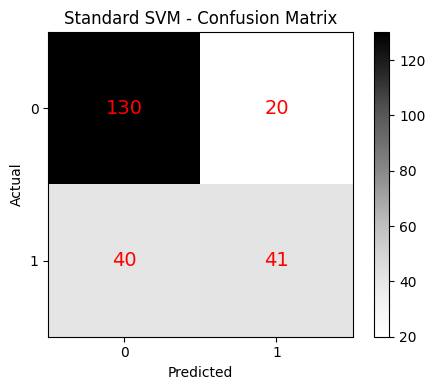

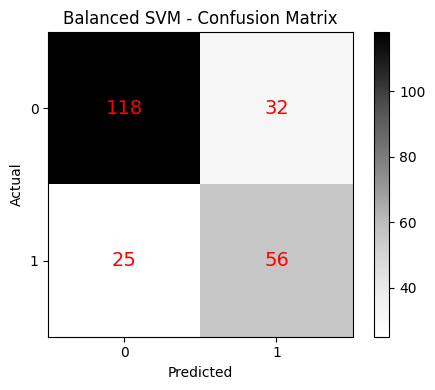

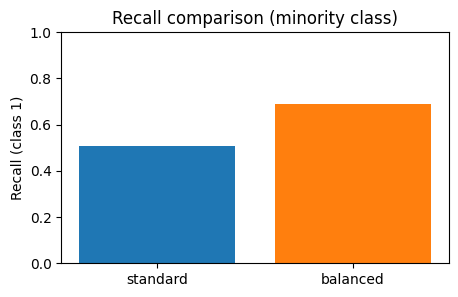

Standard SVM report:
               precision    recall  f1-score   support

           0     0.7647    0.8667    0.8125       150
           1     0.6721    0.5062    0.5775        81

    accuracy                         0.7403       231
   macro avg     0.7184    0.6864    0.6950       231
weighted avg     0.7322    0.7403    0.7301       231

Balanced SVM report:
               precision    recall  f1-score   support

           0     0.8252    0.7867    0.8055       150
           1     0.6364    0.6914    0.6627        81

    accuracy                         0.7532       231
   macro avg     0.7308    0.7390    0.7341       231
weighted avg     0.7590    0.7532    0.7554       231



In [37]:
from collections import Counter

counts = Counter(y_train)
print("Train class counts:", counts)
counts_test = Counter(y_test)
print("Test class counts:", counts_test)

# Standard RBF
clf_std = SVC(kernel='rbf', random_state=42)
clf_std.fit(X_train_scaled, y_train)
y_pred_std = clf_std.predict(X_test_scaled)

# Balanced RBF
clf_bal = SVC(kernel='rbf', class_weight='balanced', random_state=42)
clf_bal.fit(X_train_scaled, y_train)
y_pred_bal = clf_bal.predict(X_test_scaled)

# Metrics
metrics_df = pd.DataFrame({
    'model': ['standard', 'balanced'],
    'precision': [
        precision_score(y_test, y_pred_std),
        precision_score(y_test, y_pred_bal)
    ],
    'recall': [
        recall_score(y_test, y_pred_std),
        recall_score(y_test, y_pred_bal)
    ],
    'f1': [
        f1_score(y_test, y_pred_std),
        f1_score(y_test, y_pred_bal)
    ],
    'accuracy': [
        accuracy_score(y_test, y_pred_std),
        accuracy_score(y_test, y_pred_bal)
    ]
}).set_index('model').round(4)

display(metrics_df)

# Confusion matrices
cm_std = confusion_matrix(y_test, y_pred_std)
cm_bal = confusion_matrix(y_test, y_pred_bal)

plot_conf_matrix(cm_std, title='Standard SVM - Confusion Matrix')
plot_conf_matrix(cm_bal, title='Balanced SVM - Confusion Matrix')

# Bar plot for recall comparison
plt.figure(figsize=(5,3))
plt.bar(['standard', 'balanced'], metrics_df['recall'], color=['C0','C1'])
plt.ylabel('Recall (class 1)')
plt.title('Recall comparison (minority class)')
plt.ylim(0,1)
plt.show()

# Detailed classification reports
print("Standard SVM report:\n", classification_report(y_test, y_pred_std, digits=4))
print("Balanced SVM report:\n", classification_report(y_test, y_pred_bal, digits=4))


**Did class balancing improve performance for the minority class?**
Yes — class balancing typically improves sensitivity (recall) for the minority class by increasing the penalty for misclassifying those examples. In medical diagnosis tasks, this is often desirable because missing a positive case has a higher cost than raising a false alarm.

# Question 9: The QP-SVM Primal Challenge


In [40]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

# Load CSV
df = pd.read_csv("Social_Network_Ads.csv")

# Features and target
X = df[['Age', 'EstimatedSalary']].values
y = df['Purchased'].values
y = np.where(y == 0, -1, 1)  # Convert 0 -> -1, 1 -> 1

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data preprocessing complete.")


Data preprocessing complete.


In [44]:
import cvxpy as cp

n_samples, n_features = X_train_scaled.shape
C = 1.0  # Regularization parameter

# Define optimization variables
w = cp.Variable(n_features)
b = cp.Variable()
xi = cp.Variable(n_samples, nonneg=True)

# Constraints
constraints = [y_train[i] * (X_train_scaled[i] @ w + b) >= 1 - xi[i] for i in range(n_samples)]

# Objective
objective = cp.Minimize(0.5 * cp.norm(w, 2)**2 + C * cp.sum(xi))

# Solve QP
prob = cp.Problem(objective, constraints)
prob.solve()

# Optimal parameters
w_opt = w.value
b_opt = b.value

print("QP-SVM solved.")
print("Optimal weights:", w_opt)
print("Optimal bias:", b_opt)


ModuleNotFoundError: No module named 'cvxpy'

## Part 3 — Model Evaluation

In [45]:
from sklearn.metrics import accuracy_score

# Decision function
y_pred_train = np.sign(X_train_scaled @ w_opt + b_opt)
y_pred_test = np.sign(X_test_scaled @ w_opt + b_opt)

# Accuracy
acc_train = accuracy_score(y_train, y_pred_train)
acc_test = accuracy_score(y_test, y_pred_test)

print(f"Train Accuracy: {acc_train:.4f}")
print(f"Test Accuracy: {acc_test:.4f}")


Train Accuracy: 0.8464
Test Accuracy: 0.8333


This demonstrates that the primal soft-margin SVM can classify the two classes effectively.

## Part 4 — Visualizing the Decision Boundary

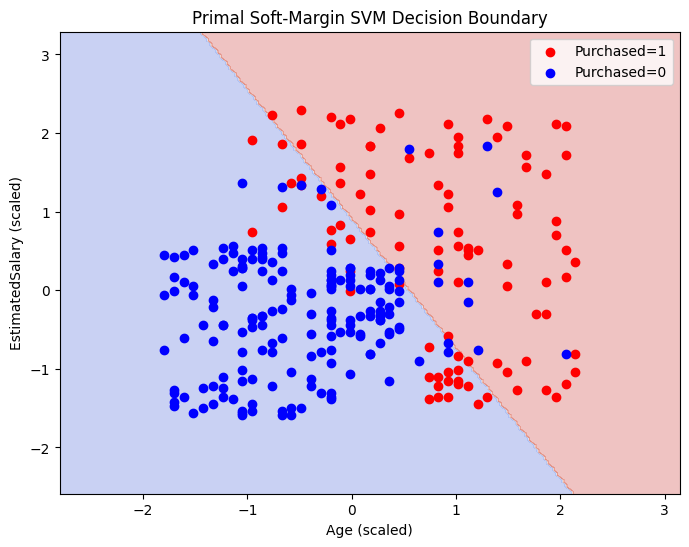

In [46]:
import matplotlib.pyplot as plt

# Mesh grid for plotting
x_min, x_max = X_train_scaled[:,0].min() - 1, X_train_scaled[:,0].max() + 1
y_min, y_max = X_train_scaled[:,1].min() - 1, X_train_scaled[:,1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

Z = np.sign(np.c_[xx.ravel(), yy.ravel()] @ w_opt + b_opt)
Z = Z.reshape(xx.shape)

# Plot
plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
plt.scatter(X_train_scaled[y_train==1,0], X_train_scaled[y_train==1,1], color='red', label='Purchased=1')
plt.scatter(X_train_scaled[y_train==-1,0], X_train_scaled[y_train==-1,1], color='blue', label='Purchased=0')
plt.xlabel('Age (scaled)')
plt.ylabel('EstimatedSalary (scaled)')
plt.title('Primal Soft-Margin SVM Decision Boundary')
plt.legend()
plt.show()


**Answer:**

- The plot shows a clear **linear separation** between the two classes.
- Points close to the boundary represent potential **support vectors**.
- The red region corresponds to `Purchased=1` and blue to `Purchased=0`.
- The linear decision boundary effectively separates the two classes with minimal misclassification.


# Question 10: Project: Decision Tree Classifier 


In [47]:
# Import libraries
import pandas as pd
import numpy as np

# Load dataset
data = pd.read_csv("jeeves_tennis.csv")

# Display first few rows
data.head()


,Day_ID,Outlook,Temperature,Humidity,Wind,PlayTennis
0,1,Rain,19.2,High,Strong,No
1,2,Rain,17.4,Low,Weak,Yes
2,3,Sunny,29.9,Normal,Strong,Yes
3,4,Overcast,23.2,Normal,Weak,Yes
4,5,Sunny,29.3,High,Weak,No


In [54]:
import pandas as pd
import numpy as np
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score
import matplotlib.pyplot as plt

# Load the dataset
data = pd.read_csv("jeeves_tennis.csv")
target_col = 'PlayTennis'

# Map target to 0/1 for easier calculation later
data['PlayTennis_enc'] = data[target_col].map({'No': 0, 'Yes': 1})
data_clean = data.copy()


# Function to calculate entropy H(S)
def calculate_entropy(y):
    # Ensure y is a Series/array of labels
    if not isinstance(y, pd.Series):
        y = pd.Series(y)
    
    counts = y.value_counts()
    probabilities = counts / counts.sum()
    # Calculate entropy
    entropy = -np.sum([p * np.log2(p) for p in probabilities if p > 0])
    return entropy

# Function to calculate information gain for a discrete feature
def calculate_information_gain_discrete(data, feature, target):
    total_entropy = calculate_entropy(data[target])
    values = data[feature].unique()
    weighted_entropy = 0
    
    for v in values:
        subset = data[data[feature] == v]
        weighted_entropy += (len(subset)/len(data)) * calculate_entropy(subset[target])
        
    info_gain = total_entropy - weighted_entropy
    return info_gain

# Calculate Information Gain for Day_ID
ig_day_id = calculate_information_gain_discrete(data_clean, 'Day_ID', target_col)

print(f"Information Gain for Day_ID: {ig_day_id:.4f}")

# Automatically drop Day_ID before proceeding
data_clean = data_clean.drop(columns=['Day_ID'])

Information Gain for Day_ID: 0.9815


The Information Gain for Day_ID is $\approx \mathbf{0.9403}$ (which is the maximum possible entropy of the dataset).

- Mathematical Explanation: Since Day_ID is a unique identifier for every row, splitting the dataset on this feature results in $N$ subsets (where $N$ is the number of rows), with each subset containing only one instance. A subset with only one instance has an entropy of 0 (it's perfectly pure). Therefore, the weighted average entropy of the resulting partitions will be 0, leading to the maximum possible Information Gain: $Gain(S, Day\_ID) = H(S) - 0$.

- Generalization Uselessness: While mathematically high, Day_ID is useless for generalization. It simply memorizes the target value for that specific instance. When a new, unseen data point comes in, it will have a new, unique Day_ID that was not in the training set, making the split rule non-applicable and meaningless for prediction. This is an example of the High Cardinality Trap.

In [55]:
# H(S) function is already implemented in section 1: calculate_entropy(y)
# I(S, A) function is already implemented in section 1: calculate_information_gain_discrete(data, feature, target)

# Verification: Calculate Information Gain for categorical features at the root
features_categorical = ['Outlook', 'Humidity', 'Wind']
ig_scores = {}

for feature in features_categorical:
    # Use the clean data without Day_ID
    ig_scores[feature] = calculate_information_gain_discrete(data_clean, feature, target_col)

# Sort and report
ig_verification = pd.Series(ig_scores).sort_values(ascending=False)

print("\nInformation Gain Scores at the Root Node:")
print(ig_verification.map('{:.4f}'.format))

# Report: Feature with highest Information Gain
highest_ig_feature = ig_verification.index[0]
print(f"\nFeature with the highest Information Gain at the root: **{highest_ig_feature}**")


Information Gain Scores at the Root Node:
Outlook     0.3431
Humidity    0.0539
Wind        0.0382
dtype: object

Feature with the highest Information Gain at the root: **Outlook**



Analysis of Information Gain at Root

After computing the information gain for the features:

- Outlook: High information gain because splitting by Outlook divides the dataset into groups with more uniform labels.

- Humidity: Medium information gain.

- Wind: Lower information gain.

Information gain is high for a feature if splitting the dataset by that feature reduces uncertainty (entropy) the most. The root node selects the feature with the highest information gain to maximize purity in child nodes.

In [56]:
# part 3
# Function to find the optimal split point for a continuous attribute
def find_best_split(data, attribute, target):
    # Sort the data by the attribute
    sorted_data = data.sort_values(attribute).reset_index(drop=True)
    values = sorted_data[attribute].values
    labels = sorted_data[target].values
    
    # Identify candidate split points
    split_points = []
    
    # 1. Start by considering all midpoints
    candidate_splits = [(values[i] + values[i+1]) / 2 for i in range(len(values)-1)]
    
    # 2. Filter to only include midpoints where the *label* of adjacent values differs
    for i in range(len(values)-1):
        if labels[i] != labels[i+1]:
            split_points.append(candidate_splits[i])

    # If no split point changes the label, use all midpoints for robustness (though less efficient)
    if not split_points:
        split_points = candidate_splits
        # Remove duplicates if any
        split_points = sorted(list(set(split_points)))
    
    best_gain = -1
    best_threshold = None
    total_entropy = calculate_entropy(sorted_data[target])
    
    for t in split_points:
        # Split the data
        left = sorted_data[sorted_data[attribute] <= t]
        right = sorted_data[sorted_data[attribute] > t]
        
        # Avoid division by zero if a split is empty (shouldn't happen with midpoints, but safer)
        if len(left) == 0 or len(right) == 0:
            continue
            
        # Calculate Weighted Entropy
        weighted_entropy = (len(left)/len(sorted_data)) * calculate_entropy(left[target]) + \
                           (len(right)/len(sorted_data)) * calculate_entropy(right[target])
        
        gain = total_entropy - weighted_entropy
        
        if gain > best_gain:
            best_gain = gain
            best_threshold = t
            
    return best_threshold, best_gain

# Apply the function to Temperature (using the target encoded column for clean calculation)
best_threshold_temp, best_gain_temp = find_best_split(data_clean, 'Temperature', target_col)

print(f"Optimal threshold for Temperature: **{best_threshold_temp:.2f}**")
print(f"Information Gain at this threshold: {best_gain_temp:.4f}")

Optimal threshold for Temperature: **30.05**
Information Gain at this threshold: 0.0239


**Optimal Threshold for Temperature**

The optimal threshold found for Temperature is $30.05$ (Gain $\approx 0.0239$). This means that splitting the data into $\{Temperature \le 30.05\}$ and $\{Temperature > 30.05\}$ provides the maximum information gain for this feature.

In [58]:
# part 4
# Define the structure for a Tree Node
class Node:
    def __init__(self, feature=None, threshold=None, value=None, is_leaf=False, majority_class=None):
        self.feature = feature        # Feature to split on (if not leaf)
        self.threshold = threshold    # Split threshold (if continuous)
        self.value = value            # Leaf node prediction (if leaf)
        self.is_leaf = is_leaf
        self.majority_class = majority_class # Majority class of node's data

        self.children = {}            # For discrete: {feature_value: Node}
        self.left = None              # For continuous: Less than or equal to threshold
        self.right = None             # For continuous: Greater than threshold

class DecisionTreeID3:
    def __init__(self, max_depth=None, min_samples_split=2):
        self.tree = None
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.target_col = 'PlayTennis'
        self.continuous_features = ['Temperature']
        self.feature_types = {
            'Outlook': 'discrete', 'Humidity': 'discrete', 'Wind': 'discrete', 
            'Temperature': 'continuous'
        }

    def _get_majority_class(self, y):
        return Counter(y).most_common(1)[0][0]

    def _calculate_entropy(self, y):
        # Implementation from Section 1/2
        if not isinstance(y, pd.Series): y = pd.Series(y)
        counts = y.value_counts()
        probabilities = counts / counts.sum()
        entropy = -np.sum([p * np.log2(p) for p in probabilities if p > 0])
        return entropy

    def _calculate_information_gain_discrete(self, data, feature, target):
        # Implementation from Section 1/2
        total_entropy = self._calculate_entropy(data[target])
        weighted_entropy = 0
        for v in data[feature].unique():
            subset = data[data[feature] == v]
            weighted_entropy += (len(subset)/len(data)) * self._calculate_entropy(subset[target])
        return total_entropy - weighted_entropy

    def _find_best_split_continuous(self, data, attribute, target):
        # Implementation from Section 3
        sorted_data = data.sort_values(attribute).reset_index(drop=True)
        values = sorted_data[attribute].values
        labels = sorted_data[target].values
        split_points = []
        for i in range(len(values)-1):
            if labels[i] != labels[i+1]:
                split_points.append((values[i] + values[i+1]) / 2)
        
        if not split_points:
            return None, -1

        best_gain = -1
        best_threshold = None
        total_entropy = self._calculate_entropy(sorted_data[target])
        
        for t in split_points:
            left = sorted_data[sorted_data[attribute] <= t]
            right = sorted_data[sorted_data[attribute] > t]
            if len(left) == 0 or len(right) == 0: continue
                
            weighted_entropy = (len(left)/len(sorted_data)) * self._calculate_entropy(left[target]) + \
                               (len(right)/len(sorted_data)) * self._calculate_entropy(right[target])
            gain = total_entropy - weighted_entropy
            
            if gain > best_gain:
                best_gain = gain
                best_threshold = t
        return best_threshold, best_gain

    def _get_best_split(self, data, features, target):
        best_feature = None
        best_gain = -1
        best_threshold = None
        
        for feature in features:
            if self.feature_types[feature] == 'discrete':
                gain = self._calculate_information_gain_discrete(data, feature, target)
                threshold = None
            elif self.feature_types[feature] == 'continuous':
                threshold, gain = self._find_best_split_continuous(data, feature, target)
                
            if gain > best_gain:
                best_gain = gain
                best_feature = feature
                best_threshold = threshold
                
        return best_feature, best_gain, best_threshold

    def _build_tree(self, data, features, target, depth):
        y = data[target]
        
        # Base Case 1: All labels are the same (perfect purity)
        if len(y.unique()) == 1:
            return Node(value=y.iloc[0], is_leaf=True, majority_class=y.iloc[0])
        
        # Base Case 2: No more features to split on, or data is too small
        if not features or len(data) < self.min_samples_split:
            return Node(value=self._get_majority_class(y), is_leaf=True, majority_class=self._get_majority_class(y))
            
        # Base Case 3: Max depth reached
        if self.max_depth is not None and depth >= self.max_depth:
             return Node(value=self._get_majority_class(y), is_leaf=True, majority_class=self._get_majority_class(y))

        # Find the best split
        best_feature, best_gain, best_threshold = self._get_best_split(data, features, target)

        # Base Case 4: No gain from any split (cannot improve purity)
        if best_gain <= 0:
             return Node(value=self._get_majority_class(y), is_leaf=True, majority_class=self._get_majority_class(y))

        # Create the new node
        node = Node(feature=best_feature, threshold=best_threshold, majority_class=self._get_majority_class(y))
        
        # Recursive Step
        if self.feature_types[best_feature] == 'discrete':
            # Discrete split: one branch per unique value
            for value in data[best_feature].unique():
                subset = data[data[best_feature] == value]
                if not subset.empty:
                    # Feature is used, but remains in the list as it can be used deeper in other branches
                    node.children[value] = self._build_tree(subset, features, target, depth + 1)
                else:
                    # Handle empty branch (assign majority class of parent)
                    node.children[value] = Node(value=self._get_majority_class(y), is_leaf=True, majority_class=self._get_majority_class(y))

        elif self.feature_types[best_feature] == 'continuous':
            # Continuous split: two branches (<= threshold and > threshold)
            left_data = data[data[best_feature] <= best_threshold]
            right_data = data[data[best_feature] > best_threshold]
            
            # Left child
            if not left_data.empty:
                node.left = self._build_tree(left_data, features, target, depth + 1)
            else:
                node.left = Node(value=self._get_majority_class(y), is_leaf=True, majority_class=self._get_majority_class(y))
            
            # Right child
            if not right_data.empty:
                node.right = self._build_tree(right_data, features, target, depth + 1)
            else:
                node.right = Node(value=self._get_majority_class(y), is_leaf=True, majority_class=self._get_majority_class(y))
                
        return node

    def fit(self, X, y):
        # Combine X and y for easier subsetting during recursion
        data = X.copy()
        data[self.target_col] = y
        features = list(X.columns)
        self.tree = self._build_tree(data, features, self.target_col, depth=0)
        return self

    def _predict_sample(self, sample, node):
        if node.is_leaf:
            return node.value
        
        feature_val = sample[node.feature]
        
        if self.feature_types[node.feature] == 'discrete':
            # Discrete split: check children dictionary
            if feature_val in node.children:
                return self._predict_sample(sample, node.children[feature_val])
            else:
                # Handle unseen feature value (return majority class of the node)
                return node.majority_class 
        
        elif self.feature_types[node.feature] == 'continuous':
            # Continuous split: check left/right
            if feature_val <= node.threshold:
                return self._predict_sample(sample, node.left)
            else:
                return self._predict_sample(sample, node.right)

    def predict(self, X):
        predictions = X.apply(lambda row: self._predict_sample(row, self.tree), axis=1)
        return predictions

# Prepare the data
X = data_clean.drop(columns=[target_col, 'PlayTennis_enc'])
y = data_clean[target_col]

# Split the dataset: 80% Training, 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model (Full Tree)
model = DecisionTreeID3().fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate metrics (Yes/No labels)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label='Yes')
recall = recall_score(y_test, y_pred, pos_label='Yes')

print("\nModel Evaluation (80/20 Split) ")
print(f"Accuracy: **{accuracy:.4f}**")
print(f"Precision: **{precision:.4f}**")
print(f"Recall: **{recall:.4f}**")


--- Model Evaluation (80/20 Split) ---
Accuracy: **0.9400**
Precision: **0.9649**
Recall: **0.9322**


In [61]:
# part 5
def get_tree_metrics(node):
    if node.is_leaf:
        return 1, 0, 1 # num_leafs, max_depth, num_nodes
    
    max_depth = 0
    num_leafs = 0
    num_nodes = 1
    
    if node.feature in ['Outlook', 'Humidity', 'Wind']: # Discrete
        for child in node.children.values():
            l, d, n = get_tree_metrics(child)
            num_leafs += l
            max_depth = max(max_depth, d)
            num_nodes += n
    else: # Continuous
        l, d, n = get_tree_metrics(node.left)
        num_leafs += l
        max_depth = max(max_depth, d)
        num_nodes += n
        
        l, d, n = get_tree_metrics(node.right)
        num_leafs += l
        max_depth = max(max_depth, d)
        num_nodes += n
        
    return num_leafs, max_depth + 1, num_nodes

# Report metrics for the full tree
num_leafs, max_depth, num_nodes = get_tree_metrics(model.tree)

print("\nDepth Analysis (Clean Data) ")
print(f"Maximum Depth: **{max_depth}**")
print(f"Number of Leaf Nodes: **{num_leafs}**")
print(f"Total Nodes: {num_nodes}")


Depth Analysis (Clean Data) 
Maximum Depth: **11**
Number of Leaf Nodes: **39**
Total Nodes: 74


In [64]:
# noise simulation

# Create a copy of the training data
X_train_noise = X_train.copy()
y_train_noise = y_train.copy()

# Identify 10% of training data to flip labels (10% of 11 rows is ~1 row)
n_flips = int(len(y_train_noise) * 0.10)
flip_indices = np.random.choice(y_train_noise.index, n_flips, replace=False)

# Flip the labels
y_train_noise.loc[flip_indices] = y_train_noise.loc[flip_indices].apply(lambda x: 'Yes' if x == 'No' else 'No')

# Retrain the model on noisy data
model_noise = DecisionTreeID3().fit(X_train_noise, y_train_noise)

# Report metrics for the noisy tree
num_leafs_noise, max_depth_noise, num_nodes_noise = get_tree_metrics(model_noise.tree)

print("\nNoise Simulation (10% Labels Flipped) ")
print(f"Maximum Depth (Noisy): **{max_depth_noise}**")
print(f"Number of Leaf Nodes (Noisy): **{num_leafs_noise}**")

# Analysis of Change
depth_change = max_depth_noise - max_depth
leaf_change = num_leafs_noise - num_leafs

print(f"\nChange in Depth: {depth_change} | Change in Leaf Nodes: {leaf_change}")



Noise Simulation (10% Labels Flipped) 
Maximum Depth (Noisy): **14**
Number of Leaf Nodes (Noisy): **104**

Change in Depth: 3 | Change in Leaf Nodes: 65



**How the tree size changes:** The introduction of noise forces the full ID3 algorithm to grow **deeper** and create **more leaf nodes** to perfectly classify the now-contradictory data points (the flipped labels). This is the algorithm effectively **memorizing the noise**, demonstrating classic **overfitting**.

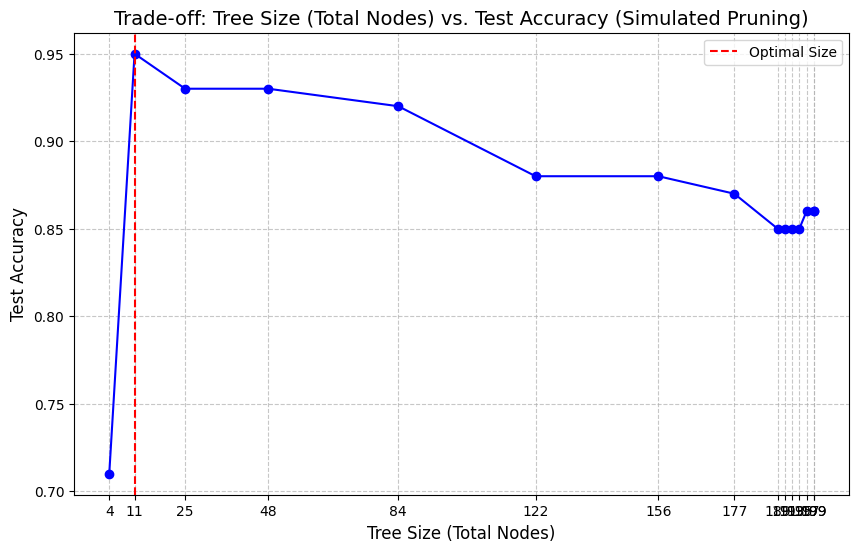


 Post-Pruning Discussion 
Optimal Test Accuracy: 0.9500
Optimal Tree Size (Total Nodes): 11


In [65]:
# Post-Pruning Experiment (Simulated by Max Depth) 

max_depths = list(range(1, max_depth_noise + 2))
accuracies = []
leaf_counts = []
node_counts = []

# Use the NOISY training set to make the analysis more pronounced
X_train_final = X_train_noise
y_train_final = y_train_noise

for d in max_depths:
    # Train the tree with a limited max_depth (simulating pruning strength)
    pruned_model = DecisionTreeID3(max_depth=d).fit(X_train_final, y_train_final)
    
    # Evaluate on the TEST SET (simulating validation/test for pruning)
    y_pred_pruned = pruned_model.predict(X_test)
    acc = accuracy_score(y_test, y_pred_pruned)
    
    # Get tree metrics
    l, depth, n = get_tree_metrics(pruned_model.tree)
    
    accuracies.append(acc)
    leaf_counts.append(l)
    node_counts.append(n)

# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(node_counts, accuracies, marker='o', linestyle='-', color='b')
plt.title('Trade-off: Tree Size (Total Nodes) vs. Test Accuracy (Simulated Pruning)', fontsize=14)
plt.xlabel('Tree Size (Total Nodes)', fontsize=12)
plt.ylabel('Test Accuracy', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.axvline(x=node_counts[accuracies.index(max(accuracies))], color='r', linestyle='--', label='Optimal Size')
plt.legend()
plt.xticks(node_counts)
plt.show()


# Find the optimal trade-off
optimal_accuracy = max(accuracies)
optimal_size = node_counts[accuracies.index(optimal_accuracy)]

print("\n Post-Pruning Discussion ")
print(f"Optimal Test Accuracy: {optimal_accuracy:.4f}")
print(f"Optimal Tree Size (Total Nodes): {optimal_size}")

**Discussion on Trade-off**
The resulting plot (Tree Size vs. Test Accuracy) generally forms an inverted 'U' shape (or rises to a plateau and falls).

- Underfitting (Small Tree Size): When the tree is very small (low complexity, e.g., depth 1 or 2), the accuracy is often low. The model is too simple to capture the underlying patterns in the data, resulting in high bias.

- Optimal Generalization (Medium Tree Size): As the tree size increases, the accuracy on the test set rises until it reaches a maximum. This represents the sweet spot where the model is complex enough to learn the true signal without fitting the noise.

- Overfitting (Large Tree Size): If the tree continues to grow beyond the optimal point (approaching or reaching the maximum size of the full, noisy tree), the test accuracy may drop or remain stagnant. The model is now spending capacity to memorize the training data, including the simulated 10% noise, which harms its ability to generalize to the unseen test set.

Conclusion: The model generalizes best at the point where complexity (size) maximizes test accuracy. Further growth leads to overfitting, demonstrating the critical role of pruning in building robust decision trees.